# Goodbook Recommendations

In [23]:
# Install the LibRecommender package
# !pip install -U LibRecommender

# added by uv package manager

In [24]:
# Import packages and configure notebook
import pandas as pd
import libreco.data
import libreco.algorithms 
from libreco.evaluation import evaluate

pd.options.display.max_rows = 99
pd.options.display.max_columns = 99

%matplotlib inline

## 1) Importing the data

This assumes the files are located in "data" folder in the folder where the notebook is

In [4]:
# Reading the ratings and book files into pandas DataFrames

df_books = pd.read_csv("data/books.csv")
df_ratings = pd.read_csv('data/ratings.csv')

df_ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


Data is loaded, ready to do some Exploratory Data Analysis...

## 2) Exploratory Data Analysis

### Ratings

In [5]:
# Check the first few rows of the ratings DataFrame
df_ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [6]:
# Check colmns and data types of the ratings DataFrame
df_ratings.info()

# Check the summary statistics of the ratings DataFrame
desc_ratings = df_ratings.describe().T
desc_ratings.style.format({
    "count": "{:,.0f}",
    "mean": "{:,.0f}",
    "std": "{:,.0f}",
    "min": "{:,.0f}",
    "25%": "{:,.0f}",
    "50%": "{:,.0f}",
    "75%": "{:,.0f}",
    "max": "{:,.0f}",
})


<class 'pandas.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


,count,mean,std,min,25%,50%,75%,max
user_id,"5,976,479","26,224","15,413",1,"12,813","25,938","39,509","53,424"
book_id,"5,976,479","2,006","2,468",1,198,885,"2,973","10,000"
rating,"5,976,479",4,1,1,3,4,5,5


<Axes: >

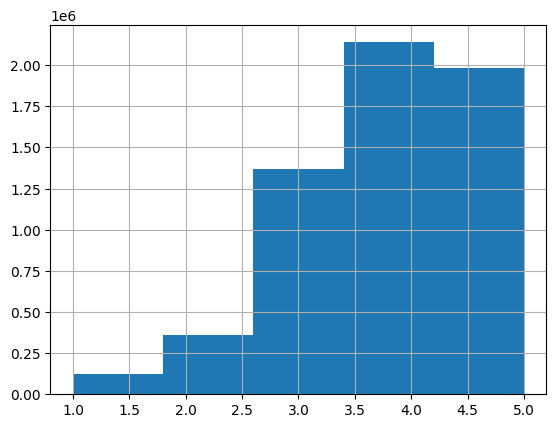

In [7]:
# Visualize the distribution of ratings using a histogram
df_ratings['rating'].hist(bins=5)

Number of users: 53,424
Total ratings: 5,976,479


,count,mean,std,min,25%,50%,75%,max
ratings_per_user,"53,424.00",111.87,26.07,19.00,96.00,111.00,128.00,200.00


Text(0, 0.5, 'Number of Users')

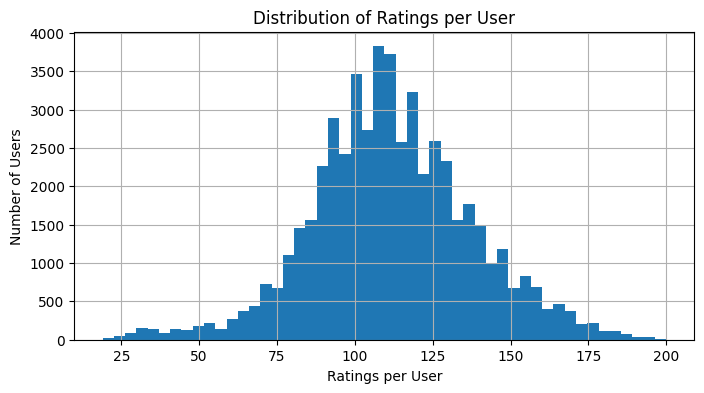

In [13]:
# Analyze "ratings per user" metric to understand whether we can rely on user-based collaborative filtering methods. If most users have only a few ratings, user-based methods may not perform well.
ratings_per_user = df_ratings.groupby("user_id").size()

print(f"Number of users: {ratings_per_user.shape[0]:,}")
print(f"Total ratings: {ratings_per_user.sum():,}")

summary = ratings_per_user.describe()
display(summary.to_frame(name="ratings_per_user").T.style.format("{:,.2f}"))

ax = ratings_per_user.hist(bins=50, figsize=(8, 4))
ax.set_title("Distribution of Ratings per User")
ax.set_xlabel("Ratings per User")
ax.set_ylabel("Number of Users")

Number of items: 10,000
Total ratings: 5,976,479


,count,mean,std,min,25%,50%,75%,max
ratings_per_item,"10,000.00",597.65,"1,267.29",8.00,155.00,248.00,503.00,"22,806.00"


Text(0, 0.5, 'Number of Items')

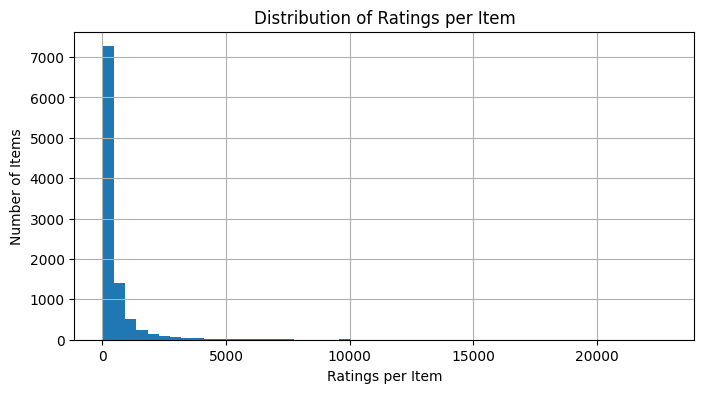

In [14]:
# Analyze "ratings per item" to assess item support in collaborative filtering
ratings_per_item = df_ratings.groupby("book_id").size()

print(f"Number of items: {ratings_per_item.shape[0]:,}")
print(f"Total ratings: {ratings_per_item.sum():,}")

summary_item = ratings_per_item.describe()
display(summary_item.to_frame(name="ratings_per_item").T.style.format("{:,.2f}"))

ax_item = ratings_per_item.hist(bins=50, figsize=(8, 4))
ax_item.set_title("Distribution of Ratings per Item")
ax_item.set_xlabel("Ratings per Item")
ax_item.set_ylabel("Number of Items")

Text(0.5, 0, 'Number of Ratings')

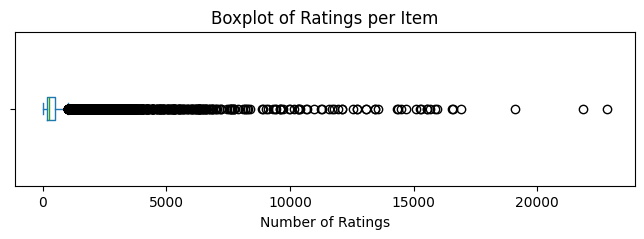

In [15]:
# Boxplot of ratings per item to inspect outliers
ax_box = ratings_per_item.plot(kind="box", vert=False, figsize=(8, 2))
ax_box.set_title("Boxplot of Ratings per Item")
ax_box.set_xlabel("Number of Ratings")

In [19]:
# Top 20 items by number of ratings in df_ratings
top_20_items = (
    ratings_per_item.sort_values(ascending=False)
    .head(20)
    .rename("ratings_in_df_ratings")
    .reset_index()
    .merge(
        df_books[["book_id", "title", "authors", "average_rating"]],
        on="book_id",
        how="left"
    )
)

top_20_items

,book_id,ratings_in_df_ratings,title,authors,average_rating
0,1,22806,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34
1,2,21850,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44
2,4,19088,To Kill a Mockingbird,Harper Lee,4.25
3,3,16931,"Twilight (Twilight, #1)",Stephenie Meyer,3.57
4,5,16604,The Great Gatsby,F. Scott Fitzgerald,3.89
5,17,16549,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30
6,20,15953,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,4.03
7,18,15855,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck",4.53
8,23,15657,Harry Potter and the Chamber of Secrets (Harry...,"J.K. Rowling, Mary GrandPré",4.37
9,7,15558,The Hobbit,J.R.R. Tolkien,4.25


In [20]:
# Check sparsity of the ratings matrix.
n_ratings = len(df_ratings)
n_users = df_ratings["user_id"].nunique()
n_books = df_ratings["book_id"].nunique()

possible = n_users * n_books
sparsity = 1 - (n_ratings / possible)
print("possible combinations:", possible)
print("sparsity:", sparsity)

possible combinations: 534240000
sparsity: 0.988813119571728


### Books

In [41]:
df_books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [36]:
desc_books = df_books.describe().T
desc_books.style.format({
    "count": "{:,.0f}",
    "mean": "{:,.0f}",
    "std": "{:,.0f}",
    "min": "{:,.0f}",
    "25%": "{:,.0f}",
    "50%": "{:,.0f}",
    "75%": "{:,.0f}",
    "max": "{:,.0f}",
})

,count,mean,std,min,25%,50%,75%,max
book_id,"10,000","5,000","2,887",1,"2,501","5,000","7,500","10,000"
goodreads_book_id,"10,000","5,264,697","7,575,462",1,"46,276","394,966","9,382,225","33,288,638"
best_book_id,"10,000","5,471,214","7,827,330",1,"47,912","425,124","9,636,112","35,534,230"
work_id,"10,000","8,646,183","11,751,061",87,"1,008,841","2,719,524","14,517,748","56,399,597"
books_count,"10,000",76,170,1,23,40,67,"3,455"
isbn13,"9,415","9,755,044,298,883","442,861,920,666","195,170,342","9,780,316,192,995","9,780,451,528,640","9,780,830,777,175","9,790,007,672,390"
original_publication_year,"9,979","1,982",153,"-1,750","1,990","2,004","2,011","2,017"
average_rating,"10,000",4,0,2,4,4,4,5
ratings_count,"10,000","54,001","157,370","2,716","13,569","21,156","41,054","4,780,653"
work_ratings_count,"10,000","59,687","167,804","5,510","15,439","23,832","45,915","4,942,365"


In [39]:
unique_book_ids = df_ratings["book_id"].unique()
print(f"Number of unique book IDs in ratings: {len(unique_book_ids)}")

Number of unique book IDs in ratings: 10000


In [43]:
# Compare work_ratings_count with the sum of ratings_1 ... ratings_5
ratings_cols = ["ratings_1", "ratings_2", "ratings_3", "ratings_4", "ratings_5"]

comparison = df_books[["book_id", "work_ratings_count"] + ratings_cols].copy()
comparison["ratings_sum"] = comparison[ratings_cols].sum(axis=1)
comparison["diff"] = comparison["work_ratings_count"] - comparison["ratings_sum"]
comparison["abs_diff"] = comparison["diff"].abs()

print("Summary of differences:")
print(comparison["diff"].describe())

exact_matches = (comparison["diff"] == 0).sum()
print(f"\nExact matches: {exact_matches}/{len(comparison)} ({exact_matches/len(comparison):.2%})")

Summary of differences:
count    10000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: diff, dtype: float64

Exact matches: 10000/10000 (100.00%)


In [47]:
# Compare rating counts and average rating in books vs ratings dataframe

# Calculate actual average rating and count from df_ratings
ratings_summary = df_ratings.groupby("book_id")["rating"].agg(
    fromratings_avg_rating="mean",
    fromratings_rating_count="count"
).reset_index()

# Merge with books dataframe
comparison_ratings = df_books[["book_id", "average_rating", "ratings_count"]].merge(
    ratings_summary, on="book_id", how="left"
)

comparison_ratings["avg_rating_diff"] = comparison_ratings["average_rating"] - comparison_ratings["fromratings_avg_rating"]
comparison_ratings["rating_count_diff"] = comparison_ratings["ratings_count"] - comparison_ratings["fromratings_rating_count"]

print("Average rating difference (books vs ratings):")
print(comparison_ratings["avg_rating_diff"].describe())
print("\nRating count difference (books vs ratings):")
print(comparison_ratings["rating_count_diff"].describe().apply("{:,.0f}".format))

comparison_ratings.head(10).style.format({
    "average_rating": "{:.2f}",
    "fromratings_avg_rating": "{:.2f}",
    "avg_rating_diff": "{:.2f}",
})

Average rating difference (books vs ratings):
count    10000.000000
mean         0.099055
std          0.096535
min         -0.511923
25%          0.039798
50%          0.091734
75%          0.150667
max          0.926667
Name: avg_rating_diff, dtype: float64

Rating count difference (books vs ratings):
count       10,000
mean        53,404
std        156,187
min          2,615
25%         13,395
50%         20,913
75%         40,572
max      4,757,847
Name: rating_count_diff, dtype: str


,book_id,average_rating,ratings_count,fromratings_avg_rating,fromratings_rating_count,avg_rating_diff,rating_count_diff
0,1,4.34,4780653,4.28,22806,0.06,4757847
1,2,4.44,4602479,4.35,21850,0.09,4580629
2,3,3.57,3866839,3.21,16931,0.36,3849908
3,4,4.25,3198671,4.33,19088,-0.08,3179583
4,5,3.89,2683664,3.77,16604,0.12,2667060
5,6,4.26,2346404,4.19,11264,0.07,2335140
6,7,4.25,2071616,4.15,15558,0.10,2056058
7,8,3.79,2044241,3.71,14472,0.08,2029769
8,9,3.85,2001311,3.60,13451,0.25,1987860
9,10,4.24,2035490,4.19,13445,0.05,2022045


In [48]:
# Show top 5 records with maximum rating count difference
top_5_max_diff = comparison_ratings.nlargest(5, 'rating_count_diff')
top_5_max_diff

,book_id,average_rating,ratings_count,fromratings_avg_rating,fromratings_rating_count,avg_rating_diff,rating_count_diff
0,1,4.34,4780653,4.279707,22806,0.060293,4757847
1,2,4.44,4602479,4.351350,21850,0.088650,4580629
2,3,3.57,3866839,3.214341,16931,0.355659,3849908
3,4,4.25,3198671,4.329369,19088,-0.079369,3179583
4,5,3.89,2683664,3.772224,16604,0.117776,2667060


In [21]:
# Calculate sparsity of the user-item interaction matrix
n_ratings = len(df_ratings)
n_users = df_ratings["user_id"].nunique()
n_books = df_ratings["book_id"].nunique()

possible = n_users * n_books
sparsity = 1 - (n_ratings / possible)
print("possible combinations:", possible)
print("sparsity:", sparsity)

possible combinations: 534240000
sparsity: 0.988813119571728


#### Observations based on the EDA

- The ratings sample has **5,976,479** interactions from **53,424** users on **10,000** books, and ratings are mostly high (**4-5**), indicating positive-feedback bias.
- The user-item space is highly sparse (about **98.9%**), so similarity estimates based on user overlap are often weak.
- User activity is long-tailed: many users have relatively few ratings, which further limits user-user collaborative filtering reliability.
- Item profiles are denser than user profiles (on average many more ratings per book than per user), making item-item similarities more stable.
- `work_ratings_count` exactly matches `ratings_1` to `ratings_5` totals for all books, confirming internal consistency of book-level rating breakdowns.
- `ratings_count` in the books table is much higher than counts in the ratings sample, suggesting the ratings file is a subset of the full Goodreads signal.

**Conclusion for modeling:** these data characteristics support starting with **item-based collaborative filtering** as a strong baseline before testing more complex models.

## Recommendations with LibRecommender package

[LibRecommender Documentation](https://librecommender.readthedocs.io/en/latest/index.html)

LibRecommender expects our columns to be named `user`, `item`, and `label`, so we need to rename the colums in `df_ratings`, [see documentation](https://librecommender.readthedocs.io/en/latest/user_guide/data_processing.html#data-processing)

In [25]:
# Modified the data frame name to keep original df_ratings for comparison and renamed columns to match LibRecommender's expected format
df_named = df_ratings.rename(
    columns={"user_id": "user", "book_id": "item", "rating": "label"},
    inplace=False
)
df_named.head()

,user,item,label
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


### Train and test dataset

The next step is to create a train (and test) set from the data for a recommender model,

e.g. using `libreco.data.random_split` [(see documentation)](https://librecommender.readthedocs.io/en/latest/api/data/split.html#libreco.data.random_split)


For more possibilities see https://librecommender.readthedocs.io/en/latest/api/data/split.html

In [26]:
# Split the data into a train and test set (20%) randomly
df_train, df_test = libreco.data.random_split(df_named, test_size=0.2)
train_data, data_info = libreco.data.DatasetPure.build_trainset(df_train)
test_data = libreco.data.DatasetPure.build_evalset(df_test)

In [27]:
# Split the data into a train and test set (20%) using split_by_ratio
df_train_ratio, df_test_ratio = libreco.data.split_by_ratio(df_named, test_size=0.2)
train_data_ratio, data_info_ratio = libreco.data.DatasetPure.build_trainset(df_train_ratio)
test_data_ratio = libreco.data.DatasetPure.build_evalset(df_test_ratio)

#### Comparison of alternative train - test splits

- **split_by_ratio(df_named, test_size=0.2)**
  - Performs a **user-level ratio split** (when possible), so users are represented in both train and test.
  - This is the **official split** for all final reported metrics.

- **random_split(df_named, test_size=0.2)**
  - Global random split across all interactions.
  - Kept for **exploratory analysis only** and **not used** in final metric reporting.

- **item-level split**
  - Useful for dedicated **cold-start item** experiments.
  - Not used for the main final benchmark.

### Recommender algorithm

Now you should be ready to try one of the [recommender algorithms](https://librecommender.readthedocs.io/en/latest/api/algorithms/index.html) and [evaluate accuracy](https://librecommender.readthedocs.io/en/latest/user_guide/evaluation_save_load.html). Below you will find a function that implements precision and recall at k.


In [32]:
def precision_recall_at_k(df_test, k=10, threshold=3.5):
    """Calculate precision and recall at k metrics for each user"""

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in df_test.groupby("user"):

        # Number of relevant items
        n_rel = sum(user_ratings["label"] >= threshold)

        # Sort user ratings by estimated value
        topk = user_ratings.sort_values(by="pred", ascending=False).head(k)

        # Number of recommended items in top k
        n_rec_k = sum((topk["pred"] >= threshold))

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(
            ((topk["label"] >= threshold) & (topk["pred"] >= threshold))
        )

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. We here set it to 0.
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. We here set it to 0.
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        
    precision_at_k = sum(precisions.values())/len(precisions)
    recall_at_k = sum(recalls.values())/len(recalls)
    
    print(f'precision at {k}:\t{precision_at_k:0.4f}')
    print(f'recall at {k}.  :\t{recall_at_k:0.4f}')

    return precision_at_k, recall_at_k

### Training two recommender models, getting predictions, comparison of results

#### Item-based collaborative filtering using the split by ratio training data

In [28]:
# Train an Item-based Nearest neighbourhood model with 20 neighbours and using Cosine similarity as similarity measure
# shows the rmse on the test set
model = libreco.algorithms.ItemCF(data_info=data_info_ratio, task="rating", sim_type="cosine", k_sim=20)
model.fit(
    train_data_ratio, 
    neg_sampling=False,
    eval_data=test_data_ratio,
    metrics=["rmse"],
    verbose=10
)

Training start time: 2026-04-22 10:03:50
Final block size and num: (10000, 1)
sim_matrix elapsed: 2.239s
sim_matrix, shape: (10000, 10000), num_elements: 43251848, density: 43.2518 %


Training start time: 2026-04-22 10:03:50
Final block size and num: (10000, 1)
sim_matrix elapsed: 2.239s
sim_matrix, shape: (10000, 10000), num_elements: 43251848, density: 43.2518 %


eval_pointwise:   1%|          | 1/146 [00:00<00:23,  6.10it/s]

Training start time: 2026-04-22 10:03:50
Final block size and num: (10000, 1)
sim_matrix elapsed: 2.239s
sim_matrix, shape: (10000, 10000), num_elements: 43251848, density: 43.2518 %


eval_pointwise:   1%|          | 1/146 [00:00<00:23,  6.10it/s]

...

Training start time: 2026-04-22 10:03:50
Final block size and num: (10000, 1)
sim_matrix elapsed: 2.239s
sim_matrix, shape: (10000, 10000), num_elements: 43251848, density: 43.2518 %


eval_pointwise:   1%|          | 1/146 [00:00<00:23,  6.10it/s]

No common interaction or similar neighbor for user 16171 and item 5561, proceed with default prediction
No common interaction or similar neighbor for user 25337 and item 585, proceed with default prediction
No common interaction or similar neighbor for user 33667 and item 2240, proceed with default prediction
No common interaction or similar neighbor for user 15755 and item 2115, proceed with default prediction
No common interaction or similar neighbor for user 8958 and item 1525, proceed with default prediction
No common interaction or similar neighbor for user 18892 and item 1287, proceed with default prediction


eval_pointwise: 100%|██████████| 146/146 [00:21<00:00,  6.77it/s]

	 eval rmse: 1.0464


In [29]:
# get a prediction of the rating for user_id 1 on book_id 2
predicted_rating = model.predict(user=1, item=2)
predicted_rating

np.float64(4.23802375793457)

In [30]:
# predict ratings for the complete test set
df_test_ratio["pred"] = model.predict(df_test_ratio["user"], df_test_ratio["item"])
df_test_ratio

,user,item,label,pred
3623535,42562,2757,3,3.121553
3985638,43232,134,4,2.804970
2983642,37244,1463,5,4.071304
5812251,53366,71,2,3.163146
2208852,29634,3339,4,3.525393
...,...,...,...,...
5145558,36367,4488,5,5.000000
2509373,32720,233,5,4.616215
1806767,24663,805,5,4.142529
172718,4547,3100,4,4.124288


In [33]:
# calculate precision at recall at K over the test set
precision, recall = precision_recall_at_k(df_test_ratio)


precision at 10:	0.6506
recall at 10.  :	0.4320


In [ ]:
import re
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

In [ ]:
books_content = df_books.copy()
books_content = books_content.drop_duplicates(subset="book_id").copy()

books_content["title"] = books_content["title"].fillna("")
books_content["original_title"] = books_content["original_title"].fillna(books_content["title"])
books_content["authors"] = books_content["authors"].fillna("")
books_content["language_code"] = books_content["language_code"].fillna("unknown")
books_content["original_publication_year"] = books_content["original_publication_year"].fillna(
    books_content["original_publication_year"].median()
)

numeric_cols = [
    "average_rating",
    "ratings_count",
    "work_ratings_count",
    "work_text_reviews_count",
    "original_publication_year",
]

for col in numeric_cols:
    books_content[col] = books_content[col].fillna(books_content[col].median())


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


books_content["content_text"] = (
    books_content["title"].map(clean_text)
    + " "
    + books_content["original_title"].map(clean_text)
    + " "
    + books_content["authors"].map(clean_text)
    + " "
    + books_content["language_code"].map(clean_text)
).str.strip()

books_content[["book_id", "title", "original_title", "authors", "language_code", "content_text"]].head()

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000,
)
text_features = tfidf.fit_transform(books_content["content_text"])

numeric_feature_cols = [
    "average_rating",
    "ratings_count",
    "work_ratings_count",
    "work_text_reviews_count",
    "original_publication_year",
]

numeric_features_df = books_content[numeric_feature_cols].copy()
for col in ["ratings_count", "work_ratings_count", "work_text_reviews_count"]:
    numeric_features_df[col] = np.log1p(numeric_features_df[col])

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_features_df)
numeric_sparse = csr_matrix(numeric_scaled)

item_feature_matrix = hstack([text_features, numeric_sparse], format="csr")

book_ids = books_content["book_id"].tolist()
book_id_to_idx = {book_id: idx for idx, book_id in enumerate(book_ids)}
idx_to_book_id = {idx: book_id for idx, book_id in enumerate(book_ids)}

print("item_feature_matrix shape:", item_feature_matrix.shape)
print("num books:", len(book_ids))

In [ ]:
def build_user_profile(user_id, train_df, item_matrix, book_id_to_idx, min_ratings=1):
    user_ratings = train_df[train_df["user"] == user_id][["item", "label"]].copy()
    user_ratings = user_ratings[user_ratings["item"].isin(book_id_to_idx)]

    if user_ratings.shape[0] < min_ratings:
        return None

    item_indices = user_ratings["item"].map(book_id_to_idx).to_numpy()
    weights = user_ratings["label"].to_numpy(dtype=float)

    user_items_matrix = item_matrix[item_indices]
    weighted_profile = user_items_matrix.multiply(weights[:, None]).sum(axis=0)
    weight_sum = np.sum(weights)

    if weight_sum == 0:
        return None

    return weighted_profile / weight_sum


def score_unseen_books(user_id, train_df, books_df, item_matrix, book_id_to_idx):
    user_profile = build_user_profile(user_id, train_df, item_matrix, book_id_to_idx)
    if user_profile is None:
        return pd.DataFrame(columns=["book_id", "score"])

    rated_books = set(train_df.loc[train_df["user"] == user_id, "item"].tolist())
    candidate_book_ids = [b for b in books_df["book_id"].tolist() if b not in rated_books]

    if not candidate_book_ids:
        return pd.DataFrame(columns=["book_id", "score"])

    candidate_indices = [book_id_to_idx[b] for b in candidate_book_ids if b in book_id_to_idx]
    candidate_book_ids = [b for b in candidate_book_ids if b in book_id_to_idx]

    candidate_matrix = item_matrix[candidate_indices]
    scores = cosine_similarity(user_profile, candidate_matrix).flatten()

    return pd.DataFrame({"book_id": candidate_book_ids, "score": scores})


def recommend_top_n_content(user_id, n, train_df, books_df, item_matrix, book_id_to_idx):
    scored = score_unseen_books(user_id, train_df, books_df, item_matrix, book_id_to_idx)
    if scored.empty:
        return pd.DataFrame(columns=["book_id", "title", "authors", "average_rating", "score"])

    top_scored = scored.sort_values("score", ascending=False).head(n)

    output = top_scored.merge(
        books_df[["book_id", "title", "authors", "average_rating"]],
        on="book_id",
        how="left",
    )

    return output[["book_id", "title", "authors", "average_rating", "score"]]

In [ ]:
target_user_id = 31933
n_recommendations = 10

content_recs_user_31933 = recommend_top_n_content(
    user_id=target_user_id,
    n=n_recommendations,
    train_df=df_train_ratio,
    books_df=books_content,
    item_matrix=item_feature_matrix,
    book_id_to_idx=book_id_to_idx,
)

print(f"Top {n_recommendations} content-based recommendations for user {target_user_id}:")
content_recs_user_31933

In [ ]:
def cosine_to_rating(score):
    if pd.isna(score):
        return np.nan
    score = np.clip(score, -1.0, 1.0)
    return 1.0 + 4.0 * ((score + 1.0) / 2.0)


global_train_mean = df_train_ratio["label"].mean()

# Build user profiles from training data only
user_profiles = {}
for uid in df_test_ratio["user"].unique():
    user_profiles[uid] = build_user_profile(
        user_id=uid,
        train_df=df_train_ratio,
        item_matrix=item_feature_matrix,
        book_id_to_idx=book_id_to_idx,
    )


def predict_content_score_for_row(user_id, item_id):
    if item_id not in book_id_to_idx:
        return np.nan

    user_profile = user_profiles.get(user_id)
    if user_profile is None:
        return np.nan

    item_vec = item_feature_matrix[book_id_to_idx[item_id]]
    score = cosine_similarity(user_profile, item_vec).flatten()[0]
    return score


content_eval_df = df_test_ratio[["user", "item", "label"]].copy()
content_eval_df["score"] = content_eval_df.apply(
    lambda row: predict_content_score_for_row(row["user"], row["item"]), axis=1
)
content_eval_df["pred"] = content_eval_df["score"].apply(cosine_to_rating)
content_eval_df["pred"] = content_eval_df["pred"].fillna(global_train_mean)

content_eval_df = content_eval_df[["user", "item", "label", "pred"]]

content_precision_at_10, content_recall_at_10 = precision_recall_at_k(content_eval_df, k=10)
content_rmse = np.sqrt(mean_squared_error(content_eval_df["label"], content_eval_df["pred"]))

print(f"Content-based RMSE: {content_rmse:.4f}")
content_eval_df.head()

In [ ]:
itemcf_rmse = np.sqrt(mean_squared_error(df_test_ratio["label"], df_test_ratio["pred"]))

comparison_df = pd.DataFrame(
    [
        {
            "Model": "ItemCF (Collaborative Filtering)",
            "RMSE": itemcf_rmse,
            "Precision@10": precision,
            "Recall@10": recall,
            "Notes": "Strong for warm-start users/items; relies on interaction history.",
        },
        {
            "Model": "Content-TFIDF (Metadata-Based)",
            "RMSE": content_rmse,
            "Precision@10": content_precision_at_10,
            "Recall@10": content_recall_at_10,
            "Notes": "Supports item cold-start via metadata; less dependent on co-ratings.",
        },
    ]
)

comparison_df

In [ ]:
target_user_id = 31933
top_n = 5

seen_train_items = set(df_train_ratio.loc[df_train_ratio["user"] == target_user_id, "item"].tolist())
all_book_ids = books_content["book_id"].tolist()
cf_candidate_items = [b for b in all_book_ids if b not in seen_train_items]

cf_scores = model.predict(
    user=np.full(len(cf_candidate_items), target_user_id),
    item=np.array(cf_candidate_items),
)

cf_recs_user_31933 = (
    pd.DataFrame({"book_id": cf_candidate_items, "score": cf_scores})
    .sort_values("score", ascending=False)
    .head(top_n)
    .merge(
        books_content[["book_id", "title", "authors", "average_rating"]],
        on="book_id",
        how="left",
    )
)

cf_recs_user_31933 = cf_recs_user_31933[
    ["book_id", "title", "authors", "average_rating", "score"]
].rename(columns={"score": "cf_pred"})

content_recs_top5_user_31933 = recommend_top_n_content(
    user_id=target_user_id,
    n=top_n,
    train_df=df_train_ratio,
    books_df=books_content,
    item_matrix=item_feature_matrix,
    book_id_to_idx=book_id_to_idx,
).rename(columns={"score": "content_score"})

print(f"Top {top_n} recommendations for user {target_user_id} - Collaborative Filtering (ItemCF)")
cf_recs_user_31933

print(f"\nTop {top_n} recommendations for user {target_user_id} - Content-Based (Metadata TF-IDF)")
content_recs_top5_user_31933

## Final Conclusion

For this dataset, ItemCF is a strong baseline because the interaction matrix is highly sparse but still has enough item-level co-rating structure to produce reliable neighborhood-based predictions for known users and known items. The metadata-based content model is complementary: it does not depend on dense co-rating overlap and therefore remains useful for item cold-start scenarios where new books have little or no interaction history. Based on these results, the bookstore should implement ItemCF as the primary production model for warm-start recommendation quality, while using the content-based model as a fallback/parallel component to improve coverage for new or weakly rated items. This reflects the main trade-off observed in the assignment: higher warm-start accuracy from collaborative filtering versus stronger cold-start flexibility from metadata-driven content methods.

#### Exploratory item-item similarity (interaction-based)

This section uses an **interaction-based item-item similarity** approach built from the user-item rating matrix.

- It is exploratory and based on rating patterns, not metadata features.
- The final **content-based recommender** for submission will instead use metadata from `books.csv`.

In [36]:
# Simple Content-Based kNN using Rating Patterns and Cosine Similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

# Step 1: Build a user-item rating matrix

rating_matrix = df_ratings.pivot_table(
    index="book_id",           # Rows are books
    columns="user_id",         # Columns are users
    values="rating",           # Values are ratings
    fill_value=0               # Empty cells = 0 (no rating)
)

# Step 2: Convert to sparse matrix for memory efficiency
X_sparse = csr_matrix(rating_matrix.values)

# Step 3: Fit kNN model using cosine similarity

knn = NearestNeighbors(n_neighbors=11, metric="cosine", algorithm="auto")
knn.fit(X_sparse)

# Step 4: Create recommendation function
def recommend_books_by_ratings(book_id, n_recommendations=10):

    # Find the index of the query book in the rating matrix
    book_idx = rating_matrix.index.get_loc(book_id)
    
    # Query kNN: find k nearest neighbors (including the query itself)
    distances, indices = knn.kneighbors(X_sparse[book_idx])
    
    # Extract neighbors (skip the first one, which is the query book itself)
    neighbor_indices = indices.flatten()[1 : n_recommendations + 1]
    neighbor_distances = distances.flatten()[1 : n_recommendations + 1]
    
    # Convert distance to similarity (1 - distance)
    # Cosine distance ranges from 0 to 1, so similarity = 1 - distance
    neighbor_similarities = 1 - neighbor_distances
    
    # Build output DataFrame
    neighbor_book_ids = rating_matrix.index[neighbor_indices].tolist()
    results = df_books[df_books["book_id"].isin(neighbor_book_ids)][
        ["book_id", "title", "authors", "average_rating"]
    ].copy()
    
    # Add similarity scores
    results["cosine_similarity"] = neighbor_similarities
    results = results.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)
    
    return results

# Step 5: Test with an example
# Book 1 is "The Hunger Games"
print("Books similar to 'The Hunger Games' (by rating pattern):")
print("=" * 80)
recommend_books_by_ratings(book_id=1, n_recommendations=10)

Books similar to 'The Hunger Games' (by rating pattern):


,book_id,title,authors,average_rating,cosine_similarity
0,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,0.723011
1,3,"Twilight (Twilight, #1)",Stephenie Meyer,3.57,0.687347
2,4,To Kill a Mockingbird,Harper Lee,4.25,0.589840
3,12,"Divergent (Divergent, #1)",Veronica Roth,4.24,0.561142
4,16,"The Girl with the Dragon Tattoo (Millennium, #1)","Stieg Larsson, Reg Keeland",4.11,0.523317
5,17,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30,0.459008
6,20,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,4.03,0.458558
7,21,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré",4.46,0.450046
8,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",4.61,0.448696
9,31,The Help,Kathryn Stockett,4.45,0.448337
